In [6]:
from typing_extensions import IntVar
import numpy as np
import random
import os
import time
import pandas as pd
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import IPython


class Process:
  def __init__(self, burst, arrival):
    self.arrival_time = arrival
    self.burst_time = burst
    self.start_time = float('inf')
    self.finish_time = float('inf')
    self.has_started = False
    self.is_over = False
    self.remaining_time = burst

  def start(self, tick, run_time):
    self.start_time = tick
    self.has_started = True
    if(self.remaining_time > run_time):
     self.remaining_time = self.remaining_time - run_time
     tick = tick + run_time
    else:
      self.finish_time = tick + self.remaining_time
      tick = tick + self.remaining_time
      self.is_over = True
      self.remaining_time = 0
    return tick

  def run(self, tick, run_time):
    if(self.remaining_time > run_time):
      self.remaining_time -= run_time
      tick = tick + run_time
    else:
      self.finish_time = tick + self.remaining_time
      tick = tick + self.remaining_time
      self.is_over = True
      self.remaining_time = 0
    return tick

def workload_gen():
  rng = np.random.default_rng()
  bursts = rng.integers(low = 1, high = 45, size = 10, endpoint = True)
  arrivals = np.sort(np.random.randint(0, 101, size = 10))
  processes = [Process(bursts[i], arrivals[i]) for i in range(10)]
  return processes

def jains_fairness(wait_times_array):
    n = len(wait_times_array)
    if n == 0 or np.sum(wait_times_array ** 2) == 0:
        return 1.0
    return (np.sum(wait_times_array) ** 2) / (n * np.sum(wait_times_array ** 2))

def random_agent(workload):
    tick = workload[0].arrival_time
    wait_times = np.zeros(0)
    turnaround_times = np.zeros(0)
    resp_times = np.zeros(0)
    rem_pro = workload[:]
    while rem_pro:
        queue = [p for p in rem_pro if p.arrival_time <= tick]
        if not queue:
            tick = min(p.arrival_time for p in rem_pro)
            queue = [p for p in rem_pro if p.arrival_time <= tick]
        p = random.choice(queue)
        p.start_time = tick
        tick += p.burst_time
        p.finish_time = tick
        p.is_over = True
        p.remaining_time = 0
        wait_times = np.append(wait_times, p.start_time - p.arrival_time)
        turnaround_times = np.append(turnaround_times, p.finish_time - p.arrival_time)
        resp_times = np.append(resp_times, p.start_time - p.arrival_time)
        rem_pro = [x for x in rem_pro if x is not p]
    mean_wait = np.mean(wait_times)
    wait_times.sort()
    P90_wait = wait_times[8]
    mean_turnaround = np.mean(turnaround_times)
    mean_resp_time = np.mean(resp_times)
    return (mean_wait, P90_wait, mean_turnaround, jains_fairness(wait_times), mean_resp_time)


def FCFS(workload):
  tick = 0
  wait_times = np.zeros(10)
  turnaround_times = np.zeros(10)
  resp_times = np.zeros(10)
  for i in range(10):
    workload[i].start_time = max(workload[i].arrival_time, tick)
    tick = workload[i].start_time + workload[i].burst_time
    workload[i].finish_time = tick
    workload[i].is_over = True
    workload[i].remaining_time = 0
    turnaround_times[i] = workload[i].finish_time - workload[i].arrival_time
    resp_times[i] = workload[i].start_time - workload[i].arrival_time
    if(i>0):
      wait_times[i] = workload[i].start_time - workload[i].arrival_time

  mean_wait = np.mean(wait_times)
  wait_times.sort()
  P90_wait = wait_times[8]
  mean_turnaround = np.mean(turnaround_times)
  mean_resp_time = np.mean(resp_times)
  return (mean_wait, P90_wait, mean_turnaround, jains_fairness(wait_times), mean_resp_time)

def SJF(workload):
  tick = 0
  wait_times = np.zeros(0)
  turnaround_times = np.zeros(0)
  resp_times = np.zeros(0)
  tick = workload[0].arrival_time
  rem_pro = workload[:]
  while rem_pro:
    queue = [p for p in rem_pro if p.arrival_time <= tick]
    if(not queue):
      tick = min(p.arrival_time for p in rem_pro)
      queue = [p for p in rem_pro if p.arrival_time <= tick]

    b = min(p.burst_time for p in queue)
    to_be_run = [p for p in queue if p.burst_time <= b]
    for p in to_be_run:
      p.is_over = True
      p.remaining_time = 0
      p.start_time = tick
      tick = tick + b
      p.finish_time = tick
      wait_times = np.append(wait_times, p.start_time - p.arrival_time)
      turnaround_times = np.append(turnaround_times, p.finish_time - p.arrival_time)
      resp_times = np.append(resp_times, p.start_time - p.arrival_time)

    rem_pro = [p for p in rem_pro if p not in to_be_run]

  mean_wait = np.mean(wait_times)
  wait_times.sort()
  P90_wait = wait_times[8]
  mean_turnaround = np.mean(turnaround_times)
  mean_resp_time = np.mean(resp_times)
  return (mean_wait, P90_wait, mean_turnaround, jains_fairness(wait_times), mean_resp_time)


def RR(workload, q):
   tick = workload[0].arrival_time
   rem_pro = workload[:]
   wait_times = np.zeros(0)
   turnaround_times = np.zeros(0)
   resp_times = np.zeros(0)
   over = []
   while rem_pro:
    for p in rem_pro:
      if(p.is_over == True):
        over.append(p)
        wait_times =  np.append(wait_times, p.finish_time - p.arrival_time - p.burst_time)
        turnaround_times = np.append(turnaround_times, p.finish_time - p.arrival_time)
        resp_times = np.append(resp_times, p.start_time - p.arrival_time)
      else:
        if(p.arrival_time <= tick):
          if(p.has_started == True):
            tick = p.run(tick, q)
          else:
            tick = p.start(tick, q)

      queue = [p for p in rem_pro if p.arrival_time <= tick]
      if not queue:
        tick = min(p.arrival_time for p in rem_pro)

    rem_pro = [p for p in rem_pro if p not in over]

   mean_wait = np.mean(wait_times)
   wait_times.sort()
   P90_wait = wait_times[8]
   mean_turnaround = np.mean(turnaround_times)
   mean_resp_time = np.mean(resp_times)
   return (mean_wait, P90_wait, mean_turnaround, jains_fairness(wait_times), mean_resp_time)


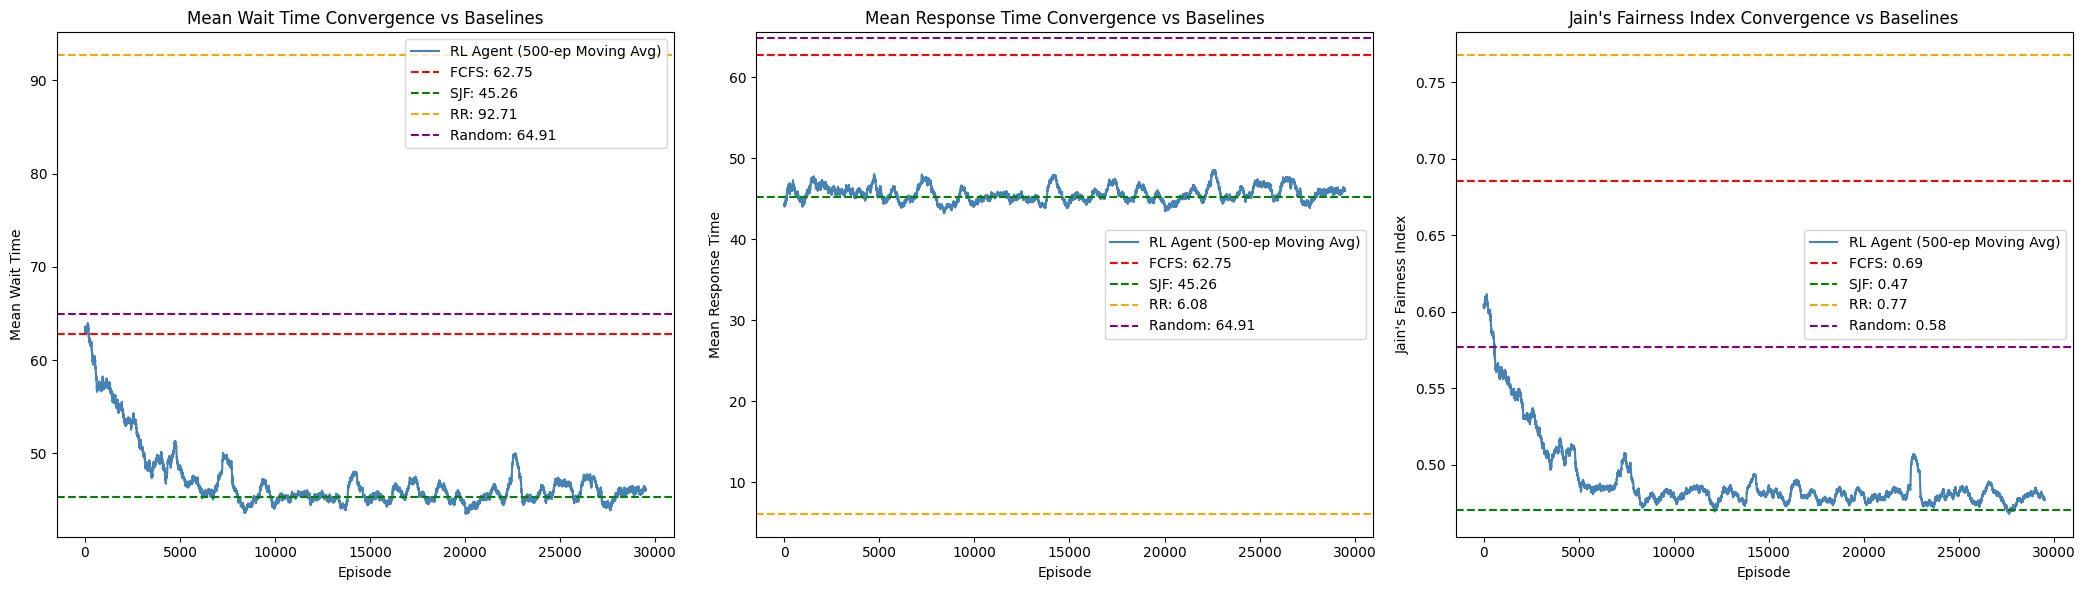

Algorithm Mean Wait P90 Wait Mean Turnaround Jains Fairness Index Mean Resp Time               Action Dist.
     FCFS     62.75   111.88           85.55                 0.69          62.75                          -
      SJF     45.26   105.87           68.29                 0.47          45.26                          -
       RR     92.71   140.38          115.57                 0.77           6.08                          -
   Random     64.91   132.76           87.97                 0.58          64.91                          -
 RL Agent     45.81   106.73           69.00                 0.48          45.81 FCFS:0 SJF:300 RR:0 Rand:0


In [9]:



class SchedulingEnv:
    def __init__(self, q=4):
        self.q = q
        self.n_actions = 4
        self.n_arrival_bins = 3
        self.n_burst_bins = 3
        self.n_states = self.n_arrival_bins * self.n_burst_bins
        self.workload = None

    def _discretize(self, processes):
        avg_arrival = np.mean([p.arrival_time for p in processes])
        avg_burst = np.mean([p.burst_time for p in processes])
        arrival_bin = min(int(avg_arrival // 30), self.n_arrival_bins - 1)
        if avg_burst < 7:
            burst_bin = 0
        elif avg_burst < 14:
            burst_bin = 1
        else:
            burst_bin = 2
        return arrival_bin * self.n_burst_bins + burst_bin

    def reset(self):
        self.workload = workload_gen()
        return self._discretize(self.workload)

    def reward(self, mean_wait, P90_wait, mean_turnaround, jains_fairness, mean_resp_time):
        reward = 30000 - 3*mean_wait*mean_wait - 1.1*mean_turnaround*mean_turnaround - 0.4*P90_wait*P90_wait + 800 * ((jains_fairness - 0.5)**2) - 2*mean_resp_time*mean_resp_time
        return reward

    def step(self, action):
        if action == 0:
            metrics = FCFS(self.workload)
        elif action == 1:
            metrics = SJF(self.workload)
        elif action == 2:
            metrics = RR(self.workload, self.q)
        else:
            metrics = random_agent(self.workload)
        mean_wait, P90_wait, mean_turnaround, jains_fairness, mean_resp_time = metrics
        r = self.reward(mean_wait, P90_wait, mean_turnaround, jains_fairness, mean_resp_time)
        self.workload = workload_gen()
        next_state = self._discretize(self.workload)
        return next_state, r, True, metrics


class QLearningAgent:
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.9,
                 epsilon=1.0, epsilon_min=0.0001, epsilon_decay=0.9995):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table = np.zeros((n_states, n_actions))

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state):
        td_target = reward + self.gamma * np.max(self.q_table[next_state])
        td_error = td_target - self.q_table[state, action]
        self.q_table[state, action] += self.alpha * td_error

    def decay_epsilon(self):
        if(self.epsilon > self.epsilon_min):
          self.epsilon = self.epsilon_decay*self.epsilon
        else:
          self.epsilon = 0



def evaluate_baselines(n_eval=200):
    results = {'FCFS': [], 'SJF': [], 'RR': [], 'Random': []}
    for _ in range(n_eval):
        results['FCFS'].append(FCFS(workload_gen()))
        results['SJF'].append(SJF(workload_gen()))
        results['RR'].append(RR(workload_gen(), 4))
        results['Random'].append(random_agent(workload_gen()))
    return {
        k: (
            np.mean([m[0] for m in v]),
            np.mean([m[1] for m in v]),
            np.mean([m[2] for m in v]),
            np.mean([m[3] for m in v]),
            np.mean([m[4] for m in v]),
        )
        for k, v in results.items()
    }


def train(n_episodes=30000):
    env = SchedulingEnv(q=4)
    agent = QLearningAgent(n_states=env.n_states, n_actions=env.n_actions)
    episode_waits = []
    episode_resp_times = []
    episode_jfis = []
    for _ in range(n_episodes):
        state = env.reset()
        action = agent.select_action(state)
        next_state, r, done, metrics = env.step(action)
        agent.update(state, action, r, next_state)
        agent.decay_epsilon()
        episode_waits.append(metrics[0])
        episode_jfis.append(metrics[3])
        episode_resp_times.append(metrics[4])
    return agent, episode_waits, episode_resp_times, episode_jfis, env


def plot_convergence(episode_waits, episode_resp_times, episode_jfis, baselines, window=500):
    palette = {'FCFS': 'red', 'SJF': 'green', 'RR': 'orange', 'Random': 'purple'}
    moving_avg_waits = np.convolve(episode_waits, np.ones(window) / window, mode='valid')
    moving_avg_resp = np.convolve(episode_resp_times, np.ones(window) / window, mode='valid')
    moving_avg_jfi = np.convolve(episode_jfis, np.ones(window) / window, mode='valid')
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    axes[0].plot(moving_avg_waits, color='steelblue', linewidth=1.5, label=f'RL Agent ({window}-ep Moving Avg)')
    for name, vals in baselines.items():
        axes[0].axhline(y=vals[0], color=palette[name], linestyle='--', linewidth=1.5, label=f'{name}: {vals[0]:.2f}')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Mean Wait Time')
    axes[0].set_title('Mean Wait Time Convergence vs Baselines')
    axes[0].legend()
    axes[1].plot(moving_avg_resp, color='steelblue', linewidth=1.5, label=f'RL Agent ({window}-ep Moving Avg)')
    for name, vals in baselines.items():
        axes[1].axhline(y=vals[4], color=palette[name], linestyle='--', linewidth=1.5, label=f'{name}: {vals[4]:.2f}')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Mean Response Time')
    axes[1].set_title('Mean Response Time Convergence vs Baselines')
    axes[1].legend()
    axes[2].plot(moving_avg_jfi, color='steelblue', linewidth=1.5, label=f'RL Agent ({window}-ep Moving Avg)')
    for name, vals in baselines.items():
        axes[2].axhline(y=vals[3], color=palette[name], linestyle='--', linewidth=1.5, label=f'{name}: {vals[3]:.2f}')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel("Jain's Fairness Index")
    axes[2].set_title("Jain's Fairness Index Convergence vs Baselines")
    axes[2].legend()
    plt.tight_layout()
    plt.show()


def run_full_pipeline(n_train=30000, n_eval=300):
    baselines = evaluate_baselines(n_eval)
    agent, episode_waits, episode_resp_times, episode_jfis, env = train(n_train)
    plot_convergence(episode_waits, episode_resp_times, episode_jfis, baselines)

    agent.epsilon = 0.0
    agent_waits, agent_p90s, agent_turns, agent_JFI, agent_resp_times = [], [], [], [], []
    action_counts = np.zeros(env.n_actions)

    for _ in range(n_eval):
        state = env.reset()
        action = agent.select_action(state)
        action_counts[action] += 1
        if action == 0:
            m = FCFS(env.workload)
        elif action == 1:
            m = SJF(env.workload)
        elif action == 2:
            m = RR(env.workload, env.q)
        else:
            m = random_agent(env.workload)
        agent_waits.append(m[0])
        agent_p90s.append(m[1])
        agent_turns.append(m[2])
        agent_JFI.append(m[3])
        agent_resp_times.append(m[4])

    df = pd.DataFrame({
        'Algorithm': list(baselines.keys()) + ['RL Agent'],
        'Mean Wait': [f'{baselines[k][0]:.2f}' for k in baselines] + [f'{np.mean(agent_waits):.2f}'],
        'P90 Wait': [f'{baselines[k][1]:.2f}' for k in baselines] + [f'{np.mean(agent_p90s):.2f}'],
        'Mean Turnaround': [f'{baselines[k][2]:.2f}' for k in baselines] + [f'{np.mean(agent_turns):.2f}'],
        'Jains Fairness Index' : [f'{baselines[k][3]:.2f}' for k in baselines] + [f'{np.mean(agent_JFI):.2f}'],
        'Mean Resp Time': [f'{baselines[k][4]:.2f}' for k in baselines] + [f'{np.mean(agent_resp_times):.2f}'],
        'Action Dist.': ['-', '-', '-', '-',
                         f'FCFS:{int(action_counts[0])} SJF:{int(action_counts[1])} RR:{int(action_counts[2])} Rand:{int(action_counts[3])}']
    })

    print(df.to_string(index=False))
    return agent, df


agent, results_df = run_full_pipeline()